# Fane Image Classification: Dataset Cleanup and Training
This notebook inspects the raw `Data/Computer-Vision/fane_data` image dataset, removes invalid and duplicate images, builds a cleaned `fane_cleaned` dataset, and creates train/validation/test splits for model training.

In [66]:
import pandas as pd
import os
from PIL import Image
import hashlib
from collections import defaultdict
import shutil
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## 1. Explore dataset structure
Count images in each class and summarize the raw dataset before cleaning.

In [ ]:
project_path = os.path.dirname(os.getcwd())
data_dir = os.path.join(project_path, "Data", "Computer-Vision", "fane_data")

class_names = []
class_counts = {}
total_images = 0

for class_name in os.listdir(data_dir):
    class_names.append(class_name)
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        image_count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        class_counts[class_name] = image_count
        total_images += image_count

# Create a structured table
df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class Name", "Image Count"]
)

print("Total images:", total_images)
print("Class names:", class_names)
df

## 2. Validate image files
Check every image for corruption and remove invalid files before continuing.

In [43]:
invalid_images = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    
    if os.path.isdir(class_path):
        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                try:
                    with Image.open(file_path) as img:
                        img.verify()   
                except Exception:
                    invalid_images.append(file_path)

print("Number of invalid/corrupted images:", len(invalid_images))

Number of invalid/corrupted images: 0


In [44]:
for img_path in invalid_images:
    os.remove(img_path)
    print("Removed:", img_path)

## Check Duplicates
check same class and cross-class duplicated images and create fane-cleaned folder for cleaned images.

In [30]:
hash_dict = {}
duplicates = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                try:
                    with open(file_path, "rb") as f:
                        file_hash = hashlib.md5(f.read()).hexdigest()

                    if file_hash in hash_dict:
                        duplicates.append({
                            "original": hash_dict[file_hash],
                            "duplicate": file_path
                        })
                    else:
                        hash_dict[file_hash] = file_path
                except Exception:
                    pass

df_duplicates = pd.DataFrame(duplicates)

print("Number of exact duplicate images found:", len(df_duplicates))
print(df_duplicates.head(20))

Number of exact duplicate images found: 4435
                                             original  \
0   d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
1   d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
2   d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
3   d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
4   d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
5   d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
6   d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
7   d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
8   d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
9   d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
10  d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
11  d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
12  d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
13  d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
14  d:\Toaa\Depi\Social-Media-Depression-Risk\Data...   
15  d:\Toaa\Depi\Social-Media-Depression-Ri

In [31]:
# add original/duplicate class names
df_duplicates["original_class"] = df_duplicates["original"].apply(lambda x: os.path.basename(os.path.dirname(x)))
df_duplicates["duplicate_class"] = df_duplicates["duplicate"].apply(lambda x: os.path.basename(os.path.dirname(x)))

# same-class vs cross-class
same_class_dups = df_duplicates[df_duplicates["original_class"] == df_duplicates["duplicate_class"]]
cross_class_dups = df_duplicates[df_duplicates["original_class"] != df_duplicates["duplicate_class"]]

print("Total duplicate pairs:", len(df_duplicates))
print("Same-class duplicates:", len(same_class_dups))
print("Cross-class duplicates:", len(cross_class_dups))

Total duplicate pairs: 4435
Same-class duplicates: 3437
Cross-class duplicates: 998

Examples of cross-class duplicates:
   original_class duplicate_class  \
4           angry        confused   
5           angry        confused   
6           angry        confused   
7           angry        confused   
8           angry        confused   
9           angry        confused   
10          angry        confused   
11          angry        confused   
12          angry        confused   
13          angry        confused   
15          angry        confused   
16          angry        confused   
17          angry        confused   
18       confused         disgust   
19       confused         disgust   
20          angry         disgust   
21       confused         disgust   
22       confused         disgust   
23       confused         disgust   
24       confused         disgust   

                                             original  \
4   d:\Toaa\Depi\Social-Media-Depression-Ris

In [51]:
cleaned_dir = os.path.join(project_path, "Data", "Computer-Vision", "fane_cleaned")

os.makedirs(cleaned_dir, exist_ok=True)

# hash -> list of file records
hash_records = defaultdict(list)

# collect all image hashes
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                try:
                    with open(file_path, "rb") as f:
                        file_hash = hashlib.md5(f.read()).hexdigest()

                    hash_records[file_hash].append({
                        "class": class_name,
                        "path": file_path,
                        "file": file_name
                    })
                except Exception:
                    pass

# create class folders in cleaned dataset
for cls in class_names:
    os.makedirs(os.path.join(cleaned_dir, cls), exist_ok=True)

kept_count = 0
removed_same_class = 0
removed_cross_class = 0

for file_hash, records in hash_records.items():
    classes_in_hash = set(r["class"] for r in records)

    # cross-class duplicate -> remove all copies
    if len(classes_in_hash) > 1:
        removed_cross_class += len(records)
        continue

    # same-class duplicates -> keep only first one
    first = records[0]
    dst_path = os.path.join(cleaned_dir, first["class"], first["file"])
    shutil.copy2(first["path"], dst_path)
    kept_count += 1

    if len(records) > 1:
        removed_same_class += (len(records) - 1)

print("Cleaning completed.")
print("Kept images:", kept_count)
print("Removed same-class duplicates:", removed_same_class)
print("Removed cross-class duplicates:", removed_cross_class)
print("Cleaned dataset saved to:", cleaned_dir)

KeyboardInterrupt: 

In [62]:
class_counts_cleaned = {}
total_cleaned = 0

for class_name in os.listdir(cleaned_dir):
    class_path = os.path.join(cleaned_dir, class_name)

    if os.path.isdir(class_path):
        image_count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        class_counts_cleaned[class_name] = image_count
        total_cleaned += image_count

print("Cleaned class counts:")
for cls, count in sorted(class_counts_cleaned.items()):
    print(f"{cls}: {count}")

print("\nTotal cleaned images:", total_cleaned)

Cleaned class counts:
angry: 1638
confused: 1164
disgust: 1224
fear: 963
happy: 1111
neutral: 1536
sad: 1032
shy: 928
surprise: 1617
test: 0
train: 0
val: 0

Total cleaned images: 11213


## Check images quality and consistency
check images with small width/height and apply manual cleaning on unsufficient images. 

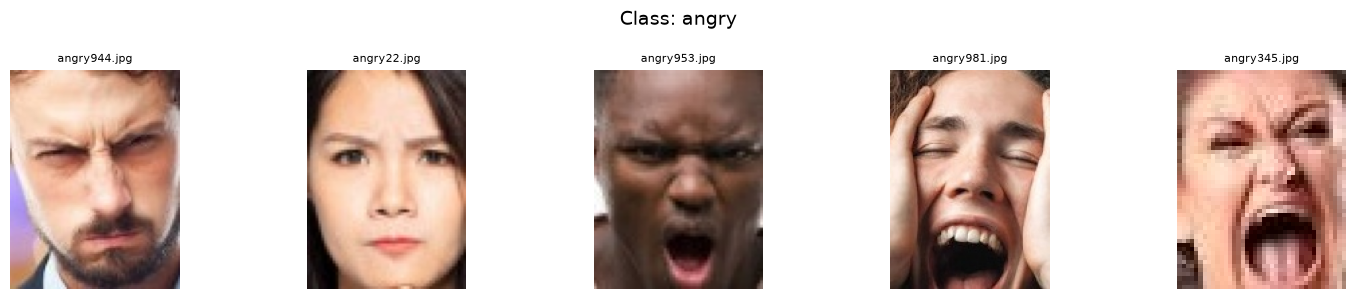

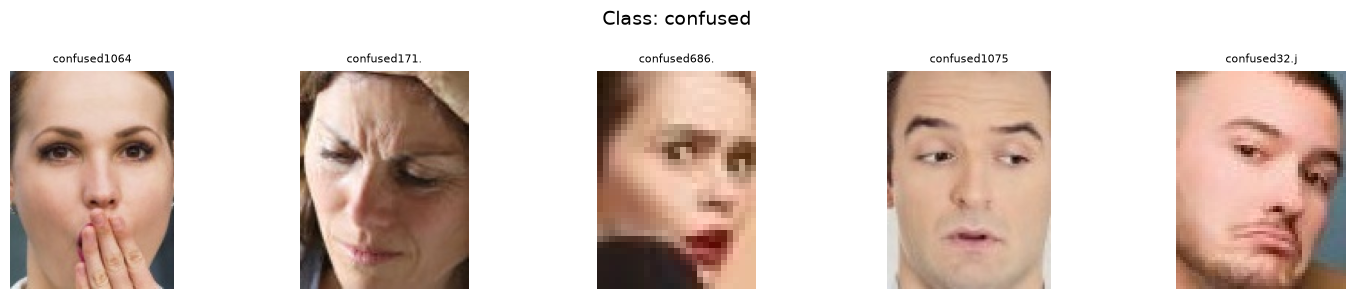

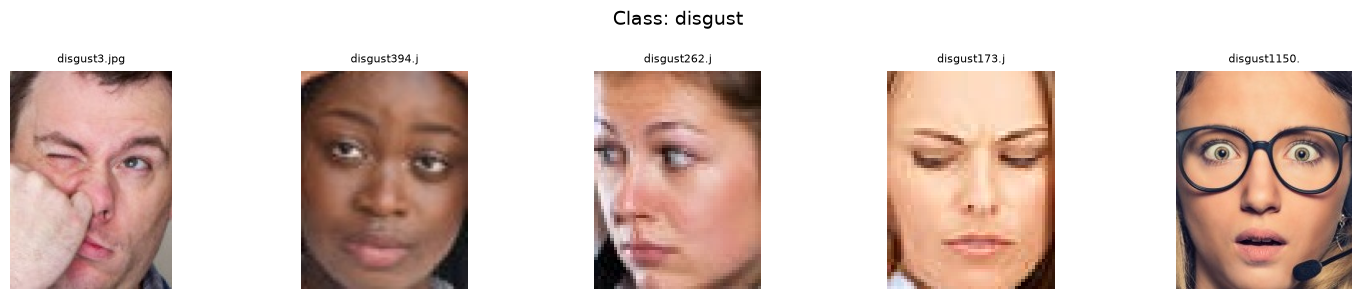

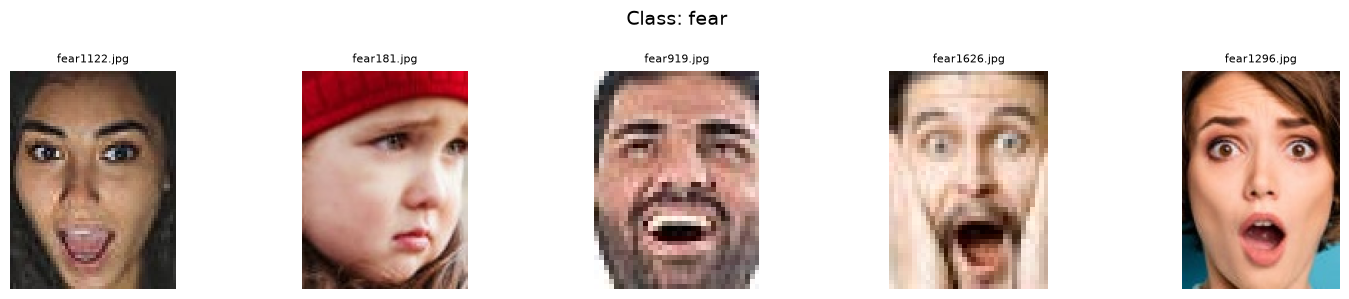

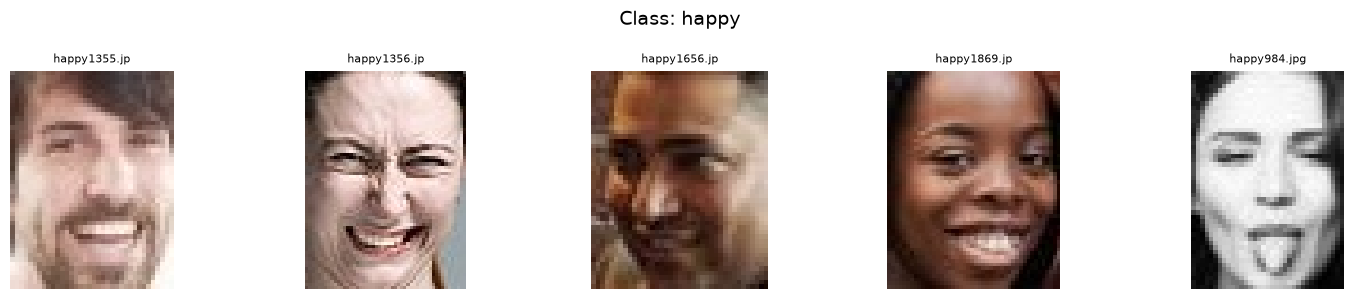

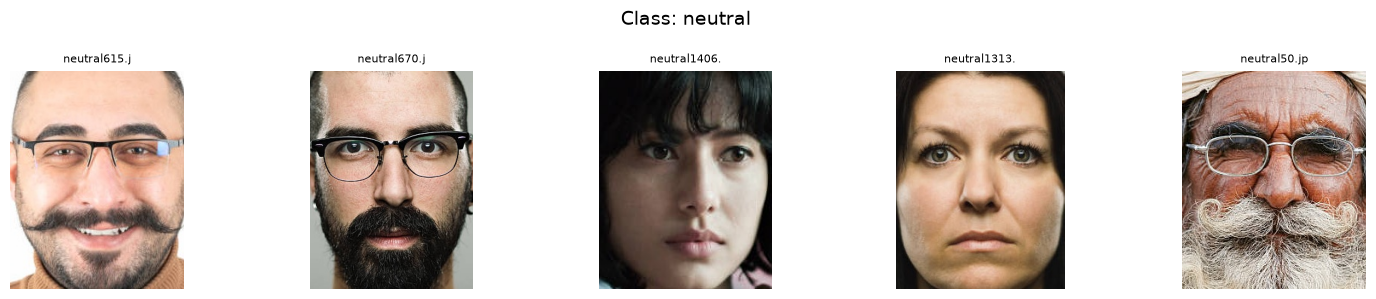

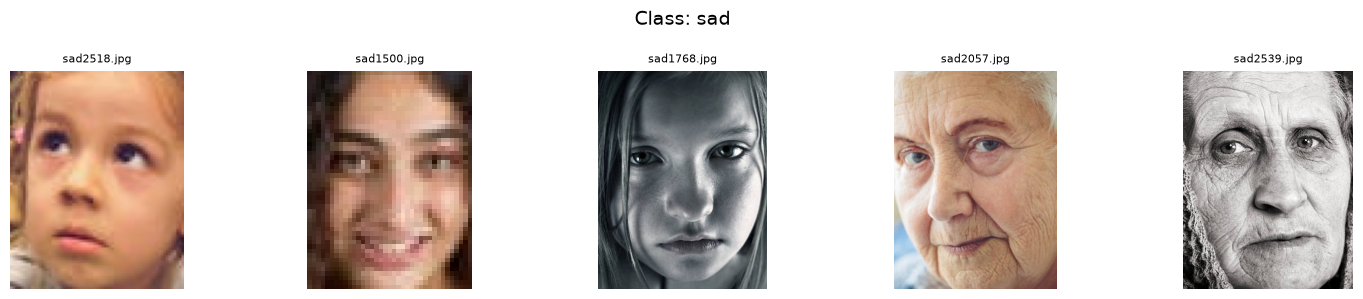

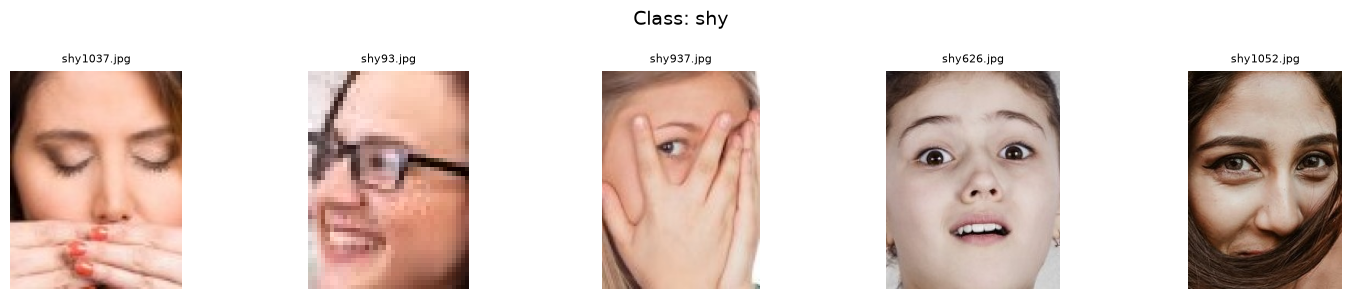

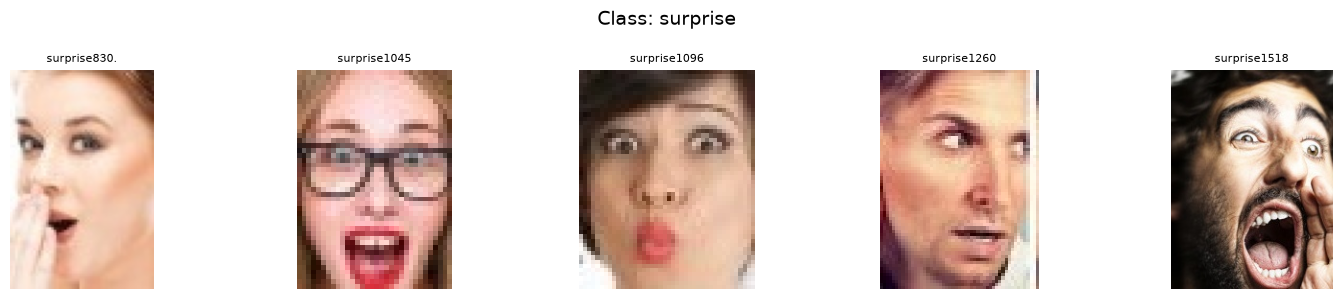

In [55]:
for cls in class_names:
    class_path = os.path.join(cleaned_dir, cls)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    sample_images = random.sample(images, min(5, len(images)))

    plt.figure(figsize=(15, 3))
    plt.suptitle(f"Class: {cls}", fontsize=14)

    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_name[:12], fontsize=8)

    plt.tight_layout()
    plt.show()

In [56]:
image_info = []

for class_name in os.listdir(cleaned_dir):
    class_path = os.path.join(cleaned_dir, class_name)

    if os.path.isdir(class_path):
        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                try:
                    with Image.open(file_path) as img:
                        width, height = img.size
                        image_info.append({
                            "class": class_name,
                            "file": file_name,
                            "path": file_path,
                            "width": width,
                            "height": height
                        })
                except Exception:
                    pass

df_sizes = pd.DataFrame(image_info)

small_imgs = df_sizes[(df_sizes["width"] < 80) | (df_sizes["height"] < 80)]

print("Number of very small images:", len(small_imgs))
print(small_imgs[["class", "file", "width", "height"]].head(20))

Number of very small images: 4489
    class           file  width  height
2   angry  angry1000.jpg     38      54
3   angry  angry1001.jpg     39      51
4   angry  angry1002.jpg     35      45
5   angry  angry1003.jpg     39      50
8   angry  angry1006.jpg     56      71
10  angry  angry1008.jpg     61      78
11  angry  angry1009.jpg     57      79
12  angry   angry101.jpg     57      66
13  angry  angry1011.jpg     30      40
14  angry  angry1012.jpg     52      69
15  angry  angry1013.jpg     76     105
17  angry  angry1015.jpg     46      59
20  angry  angry1018.jpg     78     101
22  angry   angry102.jpg     65      88
23  angry  angry1021.jpg     70     101
31  angry   angry103.jpg     77     104
33  angry  angry1031.jpg     72      96
36  angry  angry1034.jpg     48      60
37  angry  angry1035.jpg     63      79
38  angry  angry1036.jpg     61      82


In [57]:
tiny_imgs = df_sizes[(df_sizes["width"] < 40) | (df_sizes["height"] < 40)]

print("Number of very tiny images:", len(tiny_imgs))
print(tiny_imgs[["class", "file", "width", "height"]].head(30))

Number of very tiny images: 1231
     class           file  width  height
2    angry  angry1000.jpg     38      54
3    angry  angry1001.jpg     39      51
4    angry  angry1002.jpg     35      45
5    angry  angry1003.jpg     39      50
13   angry  angry1011.jpg     30      40
64   angry  angry1062.jpg     39      53
65   angry  angry1063.jpg     38      51
100  angry    angry11.jpg     22      26
119  angry  angry1118.jpg     28      37
180  angry  angry1192.jpg     37      49
242  angry  angry1264.jpg     32      41
274  angry  angry1312.jpg     33      42
364  angry  angry1423.jpg     33      42
365  angry  angry1424.jpg     32      43
366  angry  angry1425.jpg     26      34
367  angry  angry1426.jpg     23      32
430  angry  angry1514.jpg     31      40
431  angry  angry1515.jpg     21      29
441  angry  angry1526.jpg     27      35
442  angry  angry1527.jpg     32      45
447  angry  angry1535.jpg     24      30
453  angry  angry1544.jpg     33      40
457  angry  angry1552.jp

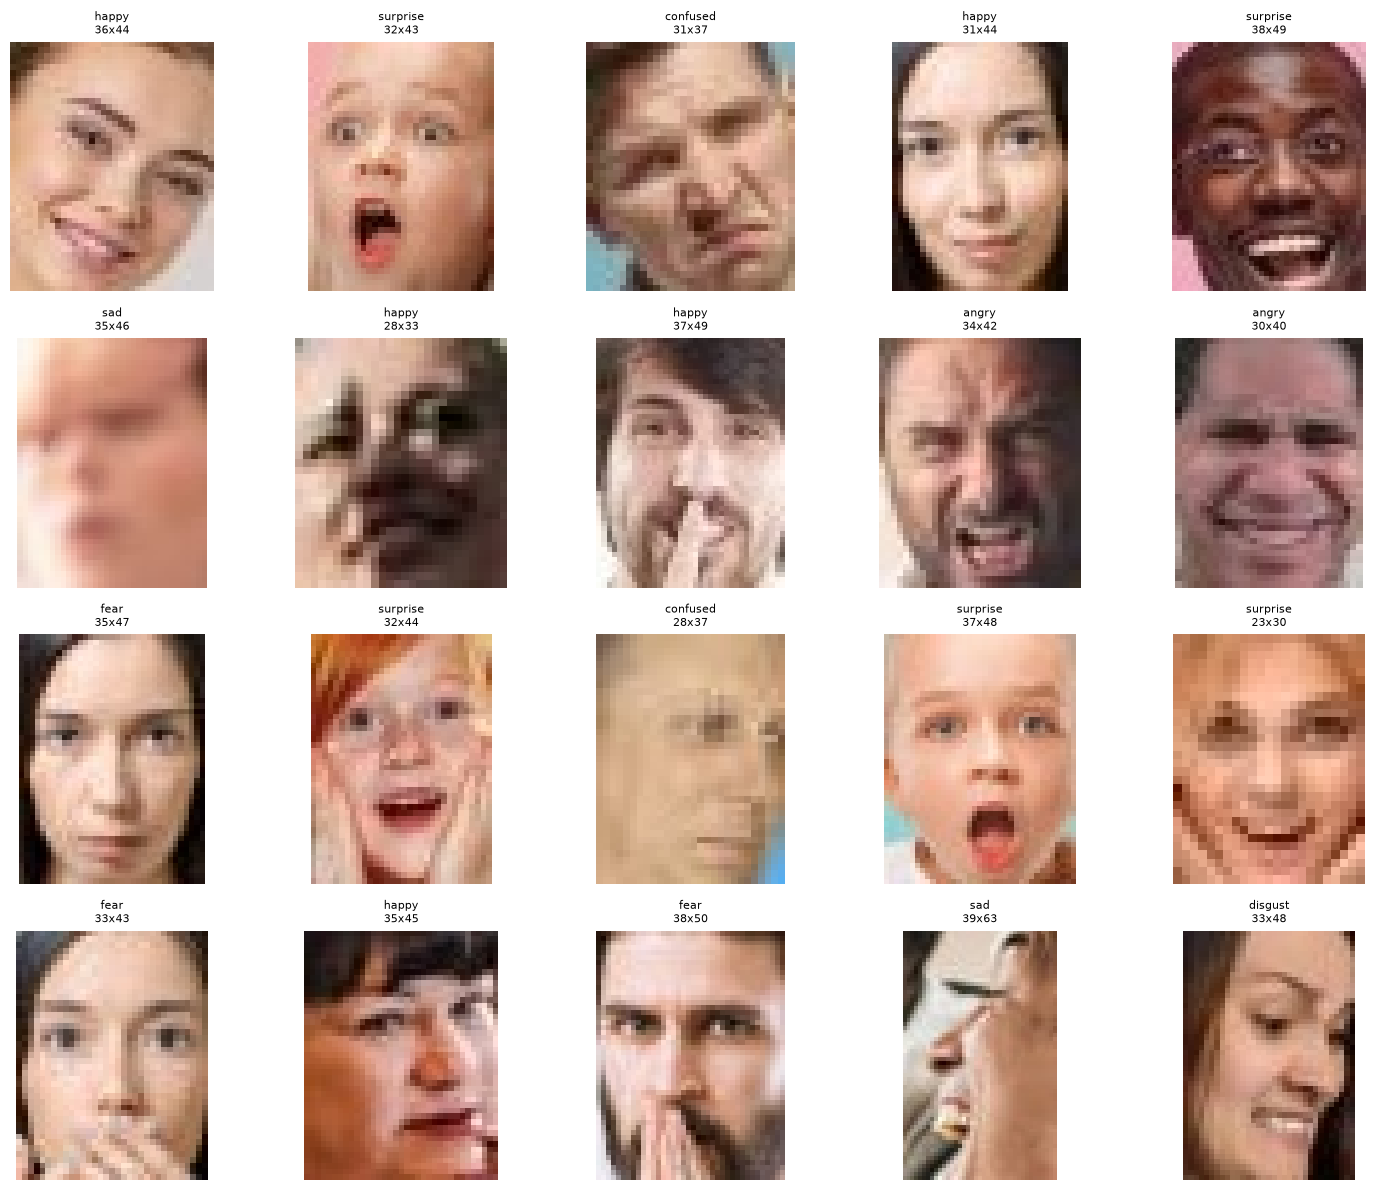

In [58]:
# tiny_imgs already created before
sample_tiny = tiny_imgs.sample(min(20, len(tiny_imgs)), random_state=42)

plt.figure(figsize=(15, 12))

for i, (_, row) in enumerate(sample_tiny.iterrows()):
    img_path = os.path.join(data_dir, row["class"], row["file"])
    img = Image.open(img_path)

    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f'{row["class"]}\n{row["width"]}x{row["height"]}', fontsize=8)

plt.tight_layout()
plt.show()

## Splitting dataset
split fane-cleaned dataset into 70% train, 15% val and 15% test for later training.

In [59]:
# create output folders
splits = ['train', 'val', 'test']

for split in splits:
    for cls in class_names:
        os.makedirs(os.path.join(cleaned_dir, split, cls), exist_ok=True)

# split each class separately
for cls in class_names:
    class_path = os.path.join(cleaned_dir, cls)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    random.shuffle(images)
    
    # 70% train, 30% temp
    train_imgs, temp_imgs = train_test_split(images, test_size=0.30, random_state=42)
    
    # split temp into 15% val, 15% test
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.50, random_state=42)

    split_map = {
        'train': train_imgs,
        'val': val_imgs,
        'test': test_imgs
    }

    for split_name, split_imgs in split_map.items():
        for img_name in split_imgs:
            src = os.path.join(class_path, img_name)
            dst = os.path.join(cleaned_dir, split_name, cls, img_name)
            shutil.copy2(src, dst)

print("Dataset split completed successfully!")
print("Output folder:", cleaned_dir)

Dataset split completed successfully!
Output folder: d:\Toaa\Depi\Social-Media-Depression-Risk\Data\Computer-Vision\fane_cleaned
